## Assignment_Week5_ Part 1

**Instructions:**

- Please submit your work as either a .ipynb notebook file or a PDF file on Blackboard.

- Please make sure your name is included either in the file name or clearly written in your assignment.


**This assignment has two parts - first, implementing decision trees, random forests, and GBRT (GBRT is optional) on the heart disease dataset. Second, we will continue with our final project. This week, we need to complete data preprocessing. Then you can choose to complete Model Selection and Training and Model Preliminary Evaluation (you can also complete these two tasks next week). In the final week, we will only have the final project assignment to finish the remaining parts, such as model optimization and final evaluation.**

<br>

<br>

### Part 1: Exploring Decision Trees, Random Forests, and GBRT on Heart Disease Data

**Goal**: In this part, we implemented and tuned Decision Trees, Random Forests, and Gradient Boosted Regression Trees(optional) on a heart disease dataset, comparing their performances to determine the best technique for the given data.

### About Dataset

#### Context
This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. 


#### Attribute Information:
- age: Age of the patient.
- sex: Gender (1 for male and 0 for female).
- cp: Chest pain type (with four distinct types represented by numbers 1-4).
- trestbps: Resting blood pressure (in mm Hg upon admission to the hospital).
- chol: Serum cholesterol in mg/dl.
- fbs: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
- restecg: Resting electrocardiographic results (values 0,1,2).
- thalach: Maximum heart rate achieved.
- exang: Exercise-induced angina (1 = yes; 0 = no).
- oldpeak: ST depression induced by exercise relative to rest.
- slope: The slope of the peak exercise ST segment.
- ca: Number of major vessels (0-3) colored by fluoroscopy.
- thal: A short for thalassemia, a blood disorder (3 = normal; 6 = fixed defect; 7 = reversible defect).


- **hd**: Presence of heart disease (1 = true; 0 = false).

<br>

### Task 1: Load the Dataset and Check Basic Information
- Check data structure, variables, and potential issues (like missing values)   
 *There's no specific requirement for what to check; choose what you feel is most relevant and informative. (for example, the shape of the dataset, Summary of the data)*

In [57]:
import os 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir('/Users/nkohei/Workspace/McDaniel-Repository/540/week5')
df = pd.read_csv('heartdisease.csv')
df.head()


,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [58]:
print("Heart Disease Data Info")

print(df.info())

print("Heart Disease Data Description")

print(df.describe())


Heart Disease Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      303 non-null    float64
 1   sex      303 non-null    float64
 2   cp       303 non-null    float64
 3   restbp   303 non-null    float64
 4   chol     303 non-null    float64
 5   fbs      303 non-null    float64
 6   restecg  303 non-null    float64
 7   thalach  303 non-null    float64
 8   exang    303 non-null    float64
 9   oldpeak  303 non-null    float64
 10  slope    303 non-null    float64
 11  ca       303 non-null    object 
 12  thal     303 non-null    object 
 13  hd       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None
Heart Disease Data Description
              age         sex          cp      restbp        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
m

### Task 2: Handle Missing Values
Ensure the dataset is free from missing values to prevent issues during modeling.
- For this dataset, missing values are represented as '?'.
- For this task, choose to simply remove all rows with missing values

In [59]:
print("Heart Disease Missing values")
print(df.apply(lambda x: (x == '?').sum()))

Heart Disease Missing values
age        0
sex        0
cp         0
restbp     0
chol       0
fbs        0
restecg    0
thalach    0
exang      0
oldpeak    0
slope      0
ca         4
thal       2
hd         0
dtype: int64


In [60]:
print("Pre-Processing Removing ? rows")
print(df.shape)

df = df.replace('?', np.nan)
df = df[~df.isnull().any(axis=1)]
print("Post-Processing Removing ? rows")
print(df.shape)


Pre-Processing Removing ? rows
(303, 14)
Post-Processing Removing ? rows
(297, 14)


### Task 3: One-Hot Encoding

- 1. Use the `pd.get_dummies()` function or an equivalent method to perform one-hot encoding 
- 2. Display the first few rows of the transformed dataset to verify the encoding.
- 3. Check the shape of the dataset after encoding

These are categorical variables and their levels in this dataset

- **sex** - **Category**
  - 0 = female
  - 1 = male
- **cp**, chest pain, **Category**
  - 1 = typical angina
  - 2 = atypical angina
  - 3 = non-anginal pain
  - 4 = asymptomatic
- **fbs**, fasting blood sugar, **Category**
  - 0 = >=120 mg/dl
  - 1 = <120 mg/dl
- **restecg**, resting electrocardiographic results, **Category**
  - 1 = normal
  - 2 = having ST-T wave abnormality
  - 3 = showing probable or definite left ventricular hypertrophy
- **exang**, exercise induced angina, **Category**
  - 0 = no
  - 1 = yes
- **slope**, the slope of the peak exercise ST segment, **Category**
  - 1 = upsloping
  - 2 = flat
  - 3 = downsloping
- **thal**, thalium heart scan, **Category**
  - 3 = normal (no cold spots)
  - 6 = fixed defect (cold spots during rest and exercise)
  - 7 = reversible defect (when cold spots only appear during exercise)

In [61]:
li_category = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in li_category:
    df[col] = df[col].astype(str)

df = pd.get_dummies(df, columns=li_category)

print(df.head())
print(df.info())


    age  restbp   chol  thalach  oldpeak   ca  hd  sex_0.0  sex_1.0  cp_1.0  \
0  63.0   145.0  233.0    150.0      2.3  0.0   0    False     True    True   
1  67.0   160.0  286.0    108.0      1.5  3.0   1    False     True   False   
2  67.0   120.0  229.0    129.0      2.6  2.0   1    False     True   False   
3  37.0   130.0  250.0    187.0      3.5  0.0   0    False     True   False   
4  41.0   130.0  204.0    172.0      1.4  0.0   0     True    False   False   

   ...  restecg_1.0  restecg_2.0  exang_0.0  exang_1.0  slope_1.0  slope_2.0  \
0  ...        False         True       True      False      False      False   
1  ...        False         True      False       True      False       True   
2  ...        False         True      False       True      False       True   
3  ...        False        False       True      False      False      False   
4  ...        False         True       True      False       True      False   

   slope_3.0  thal_3.0  thal_6.0  thal_7.0  

### Task 4: Split the Data into Training and Test Sets
  - Split the data into 75% training and 25% test sets. 
    
  - Use random_state=42
  - Verify the sizes of the training and test datasets

In [62]:
from sklearn.model_selection import train_test_split

X = df.drop('hd', axis=1)
y = df['hd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(222, 25) (75, 25) (222,) (75,)


### Task 5: Build A Preliminary Classification Tree
- Initialize a Decision Tree classifier. You can use the default parameters for the initial model.
- Fit the classifier using the training data.

- Calculate and display the accuracy of the classifier on both the training and test datasets to see its performance.


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)




Test Accuracy: 0.76
Train Accuracy: 1.0


**Question: Given the results of the Training Accuracy score and Test Accuracy score for this initial model, would you consider this model to be overfitting? Why or why not?**

Yes, because train accuracy is 1.0 and much higher than test accuracy, it means that the model is overfitting.

### Task 6: Tune Parameters of the Decision Tree

Given that we've built a preliminary decision tree, now explore how tuning parameters can influence its performance. In our decision tree lectures and the accompanying notebooks, we discussed and displayed pre-pruning. We also touched upon Cost Complexity Pruning in last week's instructional notebook. In this assignment, we practice pre-pruning using the `max_depth` parameter.
- Initialize a Decision Tree classifier. This time, set the `max_depth` parameter to 3 to limit the depth of the tree. 
- Ensure you also set `random_state=42` for consistent results.
- Fit the classifier with the training data.
- Calculate and display the accuracy of the classifier on both the training and test datasets. 

In [64]:
model = DecisionTreeClassifier(random_state=42, max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)




Test Accuracy: 0.8133333333333334
Train Accuracy: 0.8513513513513513


**Question: Based on the accuracy scores you've obtained after constraining the tree depth, how do you think limiting the max_depth parameter affects the model's ability to generalize to unseen data? Why?**

Max depth affects the ability of the model to generalize to unseen data by reducing overfitting and variance, which can lead to a slight increase in bias.

### Task 7: Explore Random Forests

Now that you've experimented with a single decision tree, let's explore how combining multiple trees can improve performance.
- Import the necessary libraries for Random Forest.
- Initialize a Random Forest classifier. *You can either build an initial model with default parameters, or choose to experiment with other parameters, such as n_estimators=100, max_depth=5*
- Fit the Random Forest classifier using the training data.
- Calculate and display the accuracy of the Random Forest classifier on both the training and test datasets. 


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)


Test Accuracy: 0.8666666666666667
Train Accuracy: 0.9459459459459459


**Question: Comparing the accuracy scores of the Random Forest and the single decision tree, which model performed better? Would we lean towards choosing the Random Forest? Why or why not?**

Random Forest has 0.86 accuracy and single decision tree has 0.81 accuracy on the test set. Given performance difference, Random Forest is better than single decision tree. Also Training Accuracy of Random Forest is better than single decision tree.

Ensemble learning helps improve generalize the model so that it can perform better on the test and unseen data set. 

### Task 8: Investigate Feature Importance with Random Forests
Gain insights into the most influential features in the dataset using the Random Forest model.

- Extract the feature importances from the trained Random Forest model. The `feature_importances_` attribute of the model provides this information.
- Optional: Visualize the feature importances using a bar chart for better clarity.

In [66]:
from sklearn.ensemble import RandomForestClassifier

# get feature importances
importances = model.feature_importances_

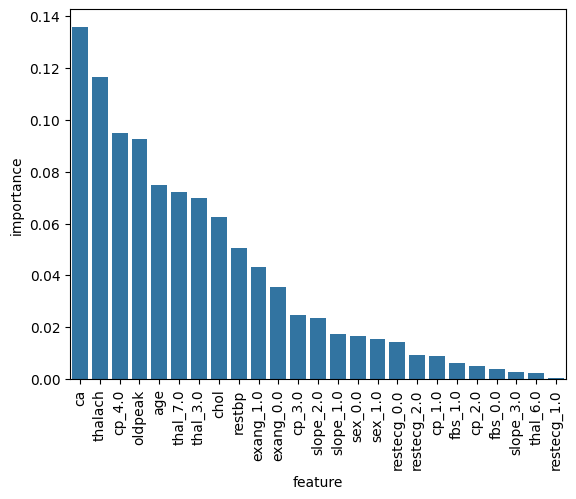

In [79]:
df_importances = pd.DataFrame(X.columns, importances)
df_importances = df_importances.reset_index()
df_importances.columns = ["importance", "feature"]



df_importances = df_importances.sort_values(by="importance", ascending=False)

sns.barplot(x="feature", y="importance", data=df_importances)
plt.xticks(rotation=90)
plt.show()


#### Question: Which features stand out as the most influential?

The number of major vessels which captured by fluroscopy is the most important feature.

### Optional Task 9: Dive into Gradient Boosted Regression Trees (GBRT)
Explore the capabilities of Gradient Boosted Regression Trees and compare its performance with other models.
- Implement a GBRT model using the training data. You can use the default parameters or experiment with settings like `n_estimators`, `learning_rate`, and `max_depth`.
- Train the GBRT model using the training dataset.
- Calculate and display the accuracy of the GBRT model on both the training and test datasets.
- Compare the performance of the GBRT model with the single decision tree and the Random Forest model you previously trained. 


In [83]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print('Test Accuracy:', test_accuracy)

train_accuracy = accuracy_score(y_train, model.predict(X_train))
print('Train Accuracy:', train_accuracy)


Test Accuracy: 0.8133333333333334
Train Accuracy: 0.9954954954954955
